In [32]:
import torch
import os 
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from PIL import Image 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [33]:
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [34]:
root_dir_path = "./img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178x218 => 178x178
    transforms.Resize(64), # 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

In [35]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [36]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

### Generator Network


In [37]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512), 
            nn.ReLU(),

            nn.Linear(512, 1024), 
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels), 
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64) 
        return img

### Discriminator Network

In [38]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D
            
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1), 
            nn.Sigmoid() # probability of being real/fake 
        )

    def forward(self, img):
        return self.model(img)

In [39]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

## Device

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device=torch.device("cpu")
print(device)

cuda


In [40]:
import torch
print(torch.cuda.is_available())

True


In [41]:
generator = generator.to(device)
discriminator = discriminator.to(device)

### Trraining The GAN

In [42]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device) 

In [43]:

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/10... batch: 1... G-loss:0.7121728658676147.... D-loss: 0.6935126185417175
for epoch: 1/10... batch: 51... G-loss:1.0015811920166016.... D-loss: 0.2682453393936157
for epoch: 1/10... batch: 101... G-loss:0.682152271270752.... D-loss: 0.5724092125892639
for epoch: 1/10... batch: 151... G-loss:0.9361611604690552.... D-loss: 0.3295761048793793
for epoch: 1/10... batch: 201... G-loss:0.7090729475021362.... D-loss: 0.35908785462379456
for epoch: 1/10... batch: 251... G-loss:2.1238291263580322.... D-loss: 0.13224416971206665
for epoch: 1/10... batch: 301... G-loss:2.7725181579589844.... D-loss: 0.11082268506288528
for epoch: 1/10... batch: 351... G-loss:0.981619656085968.... D-loss: 0.21592898666858673
for epoch: 1/10... batch: 401... G-loss:2.157818078994751.... D-loss: 0.19985167682170868
for epoch: 1/10... batch: 451... G-loss:3.048431158065796.... D-loss: 0.24262076616287231
for epoch: 1/10... batch: 501... G-loss:1.9251673221588135.... D-loss: 0.1688244640827179
for epoch: 

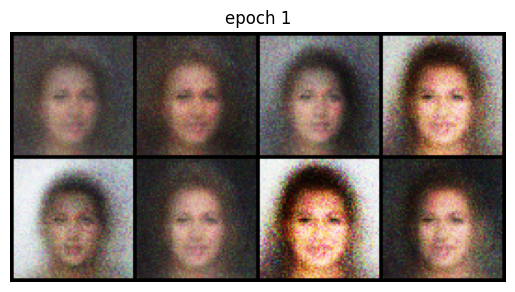

for epoch: 2/10... batch: 1... G-loss:1.6292545795440674.... D-loss: 0.2897081971168518
for epoch: 2/10... batch: 51... G-loss:3.773571014404297.... D-loss: 0.3089141845703125
for epoch: 2/10... batch: 101... G-loss:1.4858157634735107.... D-loss: 0.3692852854728699
for epoch: 2/10... batch: 151... G-loss:1.8030356168746948.... D-loss: 0.30069464445114136
for epoch: 2/10... batch: 201... G-loss:2.2848339080810547.... D-loss: 0.2688944339752197
for epoch: 2/10... batch: 251... G-loss:2.121328115463257.... D-loss: 0.43360909819602966
for epoch: 2/10... batch: 301... G-loss:1.5651953220367432.... D-loss: 0.5378240346908569
for epoch: 2/10... batch: 351... G-loss:2.587766408920288.... D-loss: 0.35151225328445435
for epoch: 2/10... batch: 401... G-loss:2.469388961791992.... D-loss: 0.2732703983783722
for epoch: 2/10... batch: 451... G-loss:1.809140682220459.... D-loss: 0.41809406876564026
for epoch: 2/10... batch: 501... G-loss:1.8936113119125366.... D-loss: 0.35315150022506714
for epoch: 2/

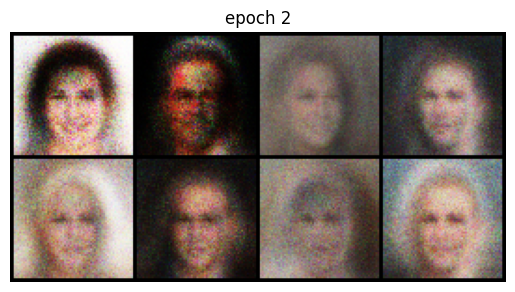

for epoch: 3/10... batch: 1... G-loss:2.1797406673431396.... D-loss: 0.44594040513038635
for epoch: 3/10... batch: 51... G-loss:1.9140453338623047.... D-loss: 0.4176347255706787
for epoch: 3/10... batch: 101... G-loss:2.3596296310424805.... D-loss: 0.4315081238746643
for epoch: 3/10... batch: 151... G-loss:1.7734081745147705.... D-loss: 0.4286160469055176
for epoch: 3/10... batch: 201... G-loss:2.465852737426758.... D-loss: 0.42623013257980347
for epoch: 3/10... batch: 251... G-loss:1.8296561241149902.... D-loss: 0.47409185767173767
for epoch: 3/10... batch: 301... G-loss:2.170837163925171.... D-loss: 0.473209947347641
for epoch: 3/10... batch: 351... G-loss:1.6053277254104614.... D-loss: 0.501751184463501
for epoch: 3/10... batch: 401... G-loss:2.1364541053771973.... D-loss: 0.36675190925598145
for epoch: 3/10... batch: 451... G-loss:2.8267581462860107.... D-loss: 0.4498838186264038
for epoch: 3/10... batch: 501... G-loss:2.1042981147766113.... D-loss: 0.389547735452652
for epoch: 3/1

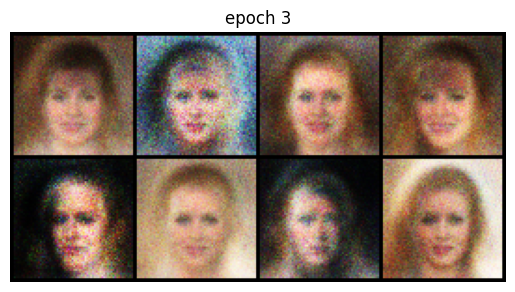

for epoch: 4/10... batch: 1... G-loss:2.0113587379455566.... D-loss: 0.5209915637969971
for epoch: 4/10... batch: 51... G-loss:1.7648766040802002.... D-loss: 0.5664277076721191
for epoch: 4/10... batch: 101... G-loss:1.919438123703003.... D-loss: 0.5123286247253418
for epoch: 4/10... batch: 151... G-loss:1.9547572135925293.... D-loss: 0.4357605576515198
for epoch: 4/10... batch: 201... G-loss:1.9097203016281128.... D-loss: 0.415290892124176
for epoch: 4/10... batch: 251... G-loss:2.1801090240478516.... D-loss: 0.3971499502658844
for epoch: 4/10... batch: 301... G-loss:1.5125412940979004.... D-loss: 0.4981078803539276
for epoch: 4/10... batch: 351... G-loss:1.8758878707885742.... D-loss: 0.4951944947242737
for epoch: 4/10... batch: 401... G-loss:1.4946057796478271.... D-loss: 0.4922821819782257
for epoch: 4/10... batch: 451... G-loss:2.3733773231506348.... D-loss: 0.4477258026599884
for epoch: 4/10... batch: 501... G-loss:1.71560800075531.... D-loss: 0.4112803041934967
for epoch: 4/10..

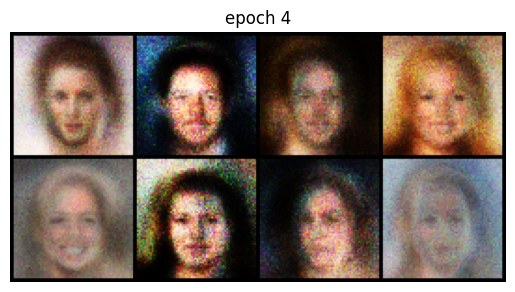

for epoch: 5/10... batch: 1... G-loss:1.6378072500228882.... D-loss: 0.5041600465774536
for epoch: 5/10... batch: 51... G-loss:1.8687794208526611.... D-loss: 0.4935986399650574
for epoch: 5/10... batch: 101... G-loss:1.558539867401123.... D-loss: 0.4741476774215698
for epoch: 5/10... batch: 151... G-loss:1.6090128421783447.... D-loss: 0.47691893577575684
for epoch: 5/10... batch: 201... G-loss:1.5825459957122803.... D-loss: 0.4571797847747803
for epoch: 5/10... batch: 251... G-loss:1.9655671119689941.... D-loss: 0.47873973846435547
for epoch: 5/10... batch: 301... G-loss:1.3776119947433472.... D-loss: 0.5226709842681885
for epoch: 5/10... batch: 351... G-loss:1.539229393005371.... D-loss: 0.5544854402542114
for epoch: 5/10... batch: 401... G-loss:1.7370338439941406.... D-loss: 0.4867159426212311
for epoch: 5/10... batch: 451... G-loss:1.6268744468688965.... D-loss: 0.5042065382003784
for epoch: 5/10... batch: 501... G-loss:1.7367877960205078.... D-loss: 0.5700191259384155
for epoch: 5/

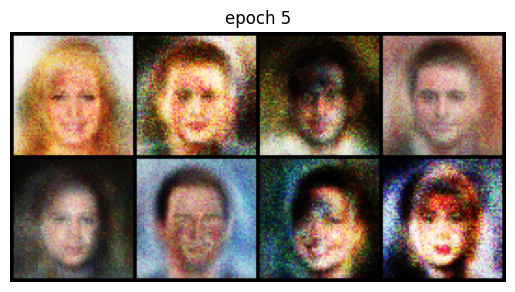

for epoch: 6/10... batch: 1... G-loss:1.731436014175415.... D-loss: 0.4996826648712158
for epoch: 6/10... batch: 51... G-loss:1.6262061595916748.... D-loss: 0.5159599184989929
for epoch: 6/10... batch: 101... G-loss:2.0107929706573486.... D-loss: 0.5740272998809814
for epoch: 6/10... batch: 151... G-loss:1.9254275560379028.... D-loss: 0.5150705575942993
for epoch: 6/10... batch: 201... G-loss:1.7798951864242554.... D-loss: 0.47985175251960754
for epoch: 6/10... batch: 251... G-loss:1.6678168773651123.... D-loss: 0.5339717268943787
for epoch: 6/10... batch: 301... G-loss:1.8343465328216553.... D-loss: 0.5173147320747375
for epoch: 6/10... batch: 351... G-loss:1.4844183921813965.... D-loss: 0.6603063344955444
for epoch: 6/10... batch: 401... G-loss:1.5220870971679688.... D-loss: 0.43736234307289124
for epoch: 6/10... batch: 451... G-loss:1.669877290725708.... D-loss: 0.4991665780544281
for epoch: 6/10... batch: 501... G-loss:1.8430087566375732.... D-loss: 0.5324610471725464
for epoch: 6/

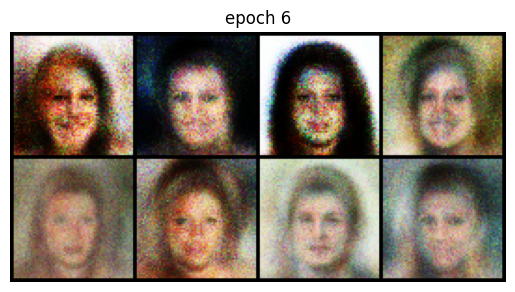

for epoch: 7/10... batch: 1... G-loss:1.8071144819259644.... D-loss: 0.5275167226791382
for epoch: 7/10... batch: 51... G-loss:1.722761869430542.... D-loss: 0.5166521072387695
for epoch: 7/10... batch: 101... G-loss:1.7105576992034912.... D-loss: 0.5448442697525024
for epoch: 7/10... batch: 151... G-loss:1.5458712577819824.... D-loss: 0.4992436170578003
for epoch: 7/10... batch: 201... G-loss:1.483670711517334.... D-loss: 0.5079048275947571
for epoch: 7/10... batch: 251... G-loss:1.6068278551101685.... D-loss: 0.5106614828109741
for epoch: 7/10... batch: 301... G-loss:1.4307857751846313.... D-loss: 0.544586718082428
for epoch: 7/10... batch: 351... G-loss:1.5887502431869507.... D-loss: 0.5355069637298584
for epoch: 7/10... batch: 401... G-loss:1.2900700569152832.... D-loss: 0.5377954244613647
for epoch: 7/10... batch: 451... G-loss:1.5988870859146118.... D-loss: 0.5664973855018616
for epoch: 7/10... batch: 501... G-loss:1.4702848196029663.... D-loss: 0.5114181041717529
for epoch: 7/10.

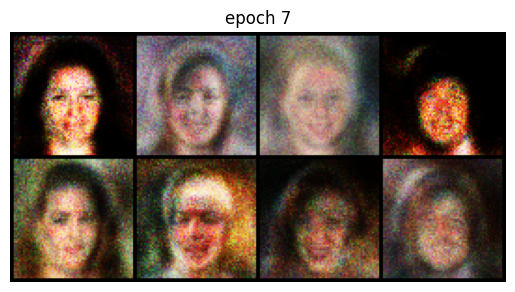

for epoch: 8/10... batch: 1... G-loss:1.3709053993225098.... D-loss: 0.6274043321609497
for epoch: 8/10... batch: 51... G-loss:1.324554681777954.... D-loss: 0.576904296875
for epoch: 8/10... batch: 101... G-loss:1.3301525115966797.... D-loss: 0.5901492238044739
for epoch: 8/10... batch: 151... G-loss:1.3322241306304932.... D-loss: 0.6029678583145142
for epoch: 8/10... batch: 201... G-loss:1.3506875038146973.... D-loss: 0.5719072818756104
for epoch: 8/10... batch: 251... G-loss:1.2028648853302002.... D-loss: 0.6341891884803772
for epoch: 8/10... batch: 301... G-loss:1.1995359659194946.... D-loss: 0.5946693420410156
for epoch: 8/10... batch: 351... G-loss:1.3946590423583984.... D-loss: 0.6186029314994812
for epoch: 8/10... batch: 401... G-loss:1.3748869895935059.... D-loss: 0.534717321395874
for epoch: 8/10... batch: 451... G-loss:1.1639548540115356.... D-loss: 0.5911455154418945
for epoch: 8/10... batch: 501... G-loss:1.3118008375167847.... D-loss: 0.5650326013565063
for epoch: 8/10... 

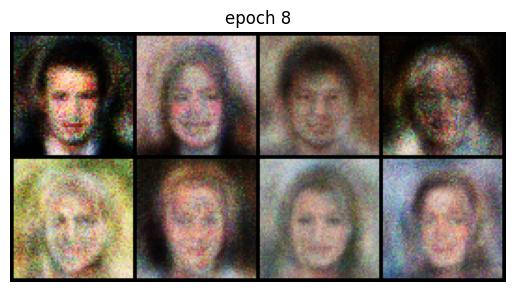

for epoch: 9/10... batch: 1... G-loss:1.2378383874893188.... D-loss: 0.5773123502731323
for epoch: 9/10... batch: 51... G-loss:1.0995283126831055.... D-loss: 0.6098778247833252
for epoch: 9/10... batch: 101... G-loss:1.3177474737167358.... D-loss: 0.5530344247817993
for epoch: 9/10... batch: 151... G-loss:1.2444353103637695.... D-loss: 0.5695862770080566
for epoch: 9/10... batch: 201... G-loss:1.4383686780929565.... D-loss: 0.5758416056632996
for epoch: 9/10... batch: 251... G-loss:1.3397916555404663.... D-loss: 0.5653858780860901
for epoch: 9/10... batch: 301... G-loss:1.2763636112213135.... D-loss: 0.5689255595207214
for epoch: 9/10... batch: 351... G-loss:1.1420176029205322.... D-loss: 0.6290741562843323
for epoch: 9/10... batch: 401... G-loss:1.3252208232879639.... D-loss: 0.6317965984344482
for epoch: 9/10... batch: 451... G-loss:1.3191430568695068.... D-loss: 0.6606866121292114
for epoch: 9/10... batch: 501... G-loss:1.378533124923706.... D-loss: 0.5499649047851562
for epoch: 9/1

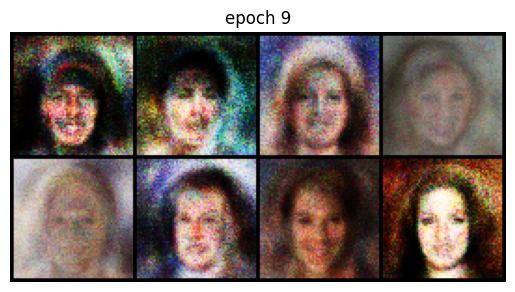

for epoch: 10/10... batch: 1... G-loss:1.2203452587127686.... D-loss: 0.5776880383491516
for epoch: 10/10... batch: 51... G-loss:1.2049027681350708.... D-loss: 0.6142935156822205
for epoch: 10/10... batch: 101... G-loss:1.5494565963745117.... D-loss: 0.6191869974136353
for epoch: 10/10... batch: 151... G-loss:1.0229365825653076.... D-loss: 0.6119762063026428
for epoch: 10/10... batch: 201... G-loss:1.2913744449615479.... D-loss: 0.5373073816299438
for epoch: 10/10... batch: 251... G-loss:1.3316373825073242.... D-loss: 0.5983145833015442
for epoch: 10/10... batch: 301... G-loss:1.2399102449417114.... D-loss: 0.5593472719192505
for epoch: 10/10... batch: 351... G-loss:1.2377698421478271.... D-loss: 0.6153092980384827
for epoch: 10/10... batch: 401... G-loss:1.276456594467163.... D-loss: 0.5816129446029663
for epoch: 10/10... batch: 451... G-loss:1.3456660509109497.... D-loss: 0.6466587781906128
for epoch: 10/10... batch: 501... G-loss:1.230279803276062.... D-loss: 0.5954481363296509
for 

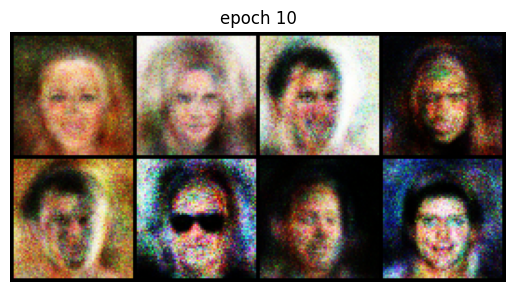

In [44]:
train(generator,discriminator,dataloader)